In [1]:
import torch
import torch.nn as nn
torch.manual_seed(42)

# Fake PIV displacement field: 100 points, each with (u, v)
uv_true = torch.randn(100, 2)

# Predicted displacements (slightly off)
uv_pred = uv_true + 0.2 * torch.randn(100, 2)

def endpoint_error_loss(pred, true):
    return torch.sqrt(((pred - true) ** 2).sum(dim=1)).mean()

loss = endpoint_error_loss(uv_pred, uv_true)
print(loss)

class EndpointErrorLoss(nn.Module):
    def forward(self, pred, true):
        return torch.sqrt(((pred - true) ** 2).sum(dim=1)).mean()

# Test it
criterion = EndpointErrorLoss()
loss = criterion(uv_pred, uv_true)
print(loss)



tensor(0.2290)
tensor(0.2290)


step   0  loss 1.2435
step  10  loss 1.1435
step  20  loss 1.0443
step  30  loss 0.9466
step  40  loss 0.8533
step  50  loss 0.7642
step  60  loss 0.6784
step  70  loss 0.5949
step  80  loss 0.5178
step  90  loss 0.4506
step 100  loss 0.3895
step 110  loss 0.3311
step 120  loss 0.2812
step 130  loss 0.2351
step 140  loss 0.1942
step 150  loss 0.1592
step 160  loss 0.1272
step 170  loss 0.0992
step 180  loss 0.0757
step 190  loss 0.0583
step   0  loss 0.9625
step  10  loss 0.7872
step  20  loss 0.6439
step  30  loss 0.5266
step  40  loss 0.4307
step  50  loss 0.3523
step  60  loss 0.2881
step  70  loss 0.2357
step  80  loss 0.1928
step  90  loss 0.1577
step 100  loss 0.1290
step 110  loss 0.1055
step 120  loss 0.0863
step 130  loss 0.0706
step 140  loss 0.0577
step 150  loss 0.0472
step 160  loss 0.0386
step 170  loss 0.0316
step 180  loss 0.0258
step 190  loss 0.0211


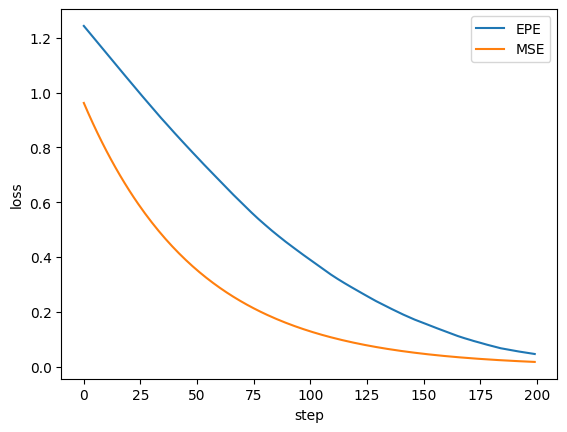

In [2]:
import matplotlib.pyplot as plt

# --- EPE ---
epe_losses = []
uv_pred = nn.Parameter(torch.zeros(100, 2))
optimiser = torch.optim.SGD([uv_pred], lr=1.0)
for step in range(200):
    optimiser.zero_grad()
    loss = criterion(uv_pred, uv_true)
    loss.backward()
    optimiser.step()
    if step % 10 == 0:
        print(f"step {step:3d}  loss {loss.item():.4f}")
    epe_losses.append(loss.item())

# --- MSE ---
mse_losses = []
uv_pred = nn.Parameter(torch.zeros(100, 2))  # reset
optimiser = torch.optim.SGD([uv_pred], lr=1.0)
mse = nn.MSELoss()
for step in range(200):
    optimiser.zero_grad()
    loss = mse(uv_pred, uv_true)
    loss.backward()
    optimiser.step()
    if step % 10 == 0:
        print(f"step {step:3d}  loss {loss.item():.4f}")
    mse_losses.append(loss.item())

plt.plot(epe_losses, label="EPE")
plt.plot(mse_losses, label="MSE")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.show()